In [1]:
import os
import sys
PROJECT_ROOT = r"D:\FYP\PlantGrowth"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
DATA_DIR = r"D:\FYP\PlantGrowth\data\stage_dataset"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("Exists:", os.path.exists(DATA_DIR))


PROJECT_ROOT: D:\FYP\PlantGrowth
DATA_DIR: D:\FYP\PlantGrowth\data\stage_dataset
Exists: True


In [2]:
# print(os.listdir(DATA_DIR))
# print(os.listdir(os.path.join(DATA_DIR, "vegetative")))
# print(os.listdir(os.path.join(DATA_DIR, "flowering")))

In [3]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from utils.dataset import StageDataset
from utils.transforms import get_stage_transforms
from models.stage_head import StageClassifier


In [4]:
# Create two independent datasets
train_base = StageDataset(
    root_dir=DATA_DIR,
    transform=get_stage_transforms(train=True)
)

val_base = StageDataset(
    root_dir=DATA_DIR,
    transform=get_stage_transforms(train=False)
)

# Split sizes
total_size = len(train_base)
val_size = int(0.2 * total_size)
train_size = total_size - val_size

# Apply identical splits
train_dataset, _ = random_split(train_base, [train_size, val_size])
_, val_dataset = random_split(val_base, [train_size, val_size])

[StageDataset] Using root_dir: D:\FYP\PlantGrowth\data\stage_dataset
[StageDataset] Checking folder: D:\FYP\PlantGrowth\data\stage_dataset\vegetative
[StageDataset] Checking folder: D:\FYP\PlantGrowth\data\stage_dataset\flowering
[StageDataset] Total images loaded: 446
[StageDataset] Using root_dir: D:\FYP\PlantGrowth\data\stage_dataset
[StageDataset] Checking folder: D:\FYP\PlantGrowth\data\stage_dataset\vegetative
[StageDataset] Checking folder: D:\FYP\PlantGrowth\data\stage_dataset\flowering
[StageDataset] Total images loaded: 446


D:\FYP\PlantGrowth\utils\transforms.py:7: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(224, 224, always_apply=True),
D:\FYP\PlantGrowth\utils\transforms.py:16: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(224, 224, always_apply=True),


In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version: 12.1


In [6]:
# DATA_DIR = "data/stage_dataset"

BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-4
VAL_SPLIT = 0.2
NUM_WORKERS = 4

SAVE_PATH = "models/stage_classifier.pth"


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


In [8]:
model = StageClassifier().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)


In [9]:
best_val_acc = 0.0
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_dataset)
    train_acc = train_correct / len(train_dataset)

    model.eval()
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_dataset)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved (Val Acc: {best_val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break


Epoch [01/20] | Train Loss: 0.5653 | Train Acc: 0.8291 | Val Acc: 0.9775
Best model saved (Val Acc: 0.9775)
Epoch [02/20] | Train Loss: 0.1733 | Train Acc: 0.9692 | Val Acc: 1.0000
Best model saved (Val Acc: 1.0000)
Epoch [03/20] | Train Loss: 0.0675 | Train Acc: 0.9832 | Val Acc: 1.0000
Epoch [04/20] | Train Loss: 0.0232 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch [05/20] | Train Loss: 0.0172 | Train Acc: 1.0000 | Val Acc: 1.0000
Epoch [06/20] | Train Loss: 0.0109 | Train Acc: 0.9944 | Val Acc: 1.0000
Epoch [07/20] | Train Loss: 0.0062 | Train Acc: 1.0000 | Val Acc: 1.0000
Early stopping triggered


In [12]:
print("Training complete")
print("Best validation accuracy:", best_val_acc)
print("Model saved at:", SAVE_PATH)


Training complete
Best validation accuracy: 1.0
Model saved at: models/stage_classifier.pth


In [14]:
model.eval()

img, label = val_dataset[0]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(DEVICE)).argmax(1).item()

print("GT label :", label)
print("Predicted:", pred)


GT label : 0
Predicted: 0


Image 0 | GT: 0


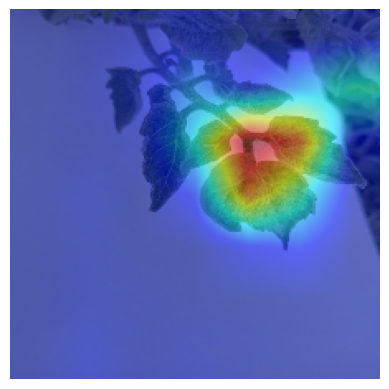

Image 1 | GT: 0


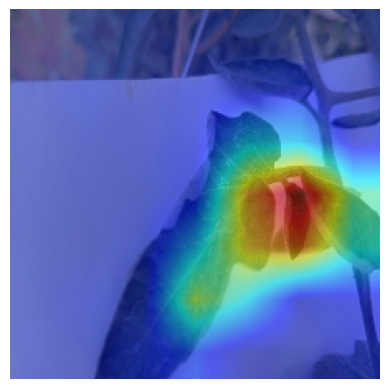

Image 2 | GT: 0


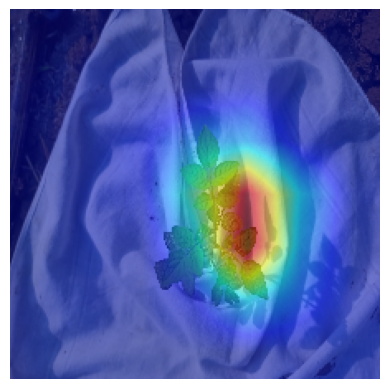

Image 3 | GT: 0


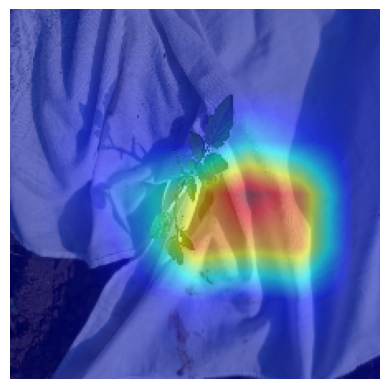

Image 4 | GT: 0


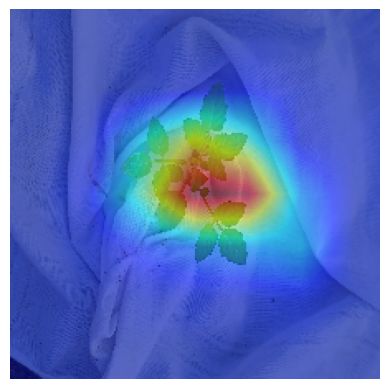

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
model.eval()

target_layers = [model.feature_extractor[-1]]  # last conv layer

cam = GradCAM(model=model, target_layers=target_layers)
for i in range(5):  # change 5 → any number
    img, label = val_dataset[i]
    input_tensor = img.unsqueeze(0).to(DEVICE)

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    print(f"Image {i} | GT:", label)
    plt.imshow(cam_image)
    plt.axis("off")
    plt.show()
